Note: This project uses simulated (synthetic) data. The dataset was generated with Python (see AI_Job_Impact_Data_Generation.ipynb), so the results do not represent the real job market.

In [4]:
# Importing core libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure that plots are displayed inside the notebook
%matplotlib inline

print("Core libraries for AI Impact on Job project loaded.")

Core libraries for AI Impact on Job project loaded.


In [5]:
# Reading the dataset for the AI Impact on Job project
df = pd.read_csv('ai_job_impact_data.csv')

# Previewing the dataset structure
df.head()

,Year,Job_Role,Vacancies,Hiring_Difficulty,Top_Required_Skill,Skill_Demand_Status,Degree_Importance,Portfolio_Weightage_Percentage,Avg_Salary_LPA
0,2024,Manual QA Tester,24,Hard,Basic Manual Testing,Declining,Low,30,3.17
1,2025,Data Analyst,174,Hard,"Python, SQL & Power BI",Growing,Medium,72,10.25
2,2026,Manual QA Tester,11,Hard,Basic Manual Testing,Declining,Low,31,3.41
3,2022,Data Entry Operator,177,Easy,Excel & Typing,Stable,High,41,3.15
4,2021,Software Engineer,241,Hard,Java / C++,Growing,High,39,5.20


In [6]:
# Checking data types and missing values in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Year                            1500 non-null   int64  
 1   Job_Role                        1500 non-null   object 
 2   Vacancies                       1500 non-null   int64  
 3   Hiring_Difficulty               1500 non-null   object 
 4   Top_Required_Skill              1500 non-null   object 
 5   Skill_Demand_Status             1500 non-null   object 
 6   Degree_Importance               1500 non-null   object 
 7   Portfolio_Weightage_Percentage  1500 non-null   int64  
 8   Avg_Salary_LPA                  1500 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 105.6+ KB


In [7]:
# Grouping by Year and calculating total vacancies and average salary
yearly_analysis = df.groupby('Year').agg({'Vacancies': 'sum', 'Avg_Salary_LPA': 'mean'}).reset_index()

# Displaying the aggregated results
yearly_analysis

,Year,Vacancies,Avg_Salary_LPA
0,2021,49735,4.984234
1,2022,44655,4.988675
2,2023,19168,7.320591
3,2024,25483,7.295061
4,2025,23862,7.172094
5,2026,27572,7.243257


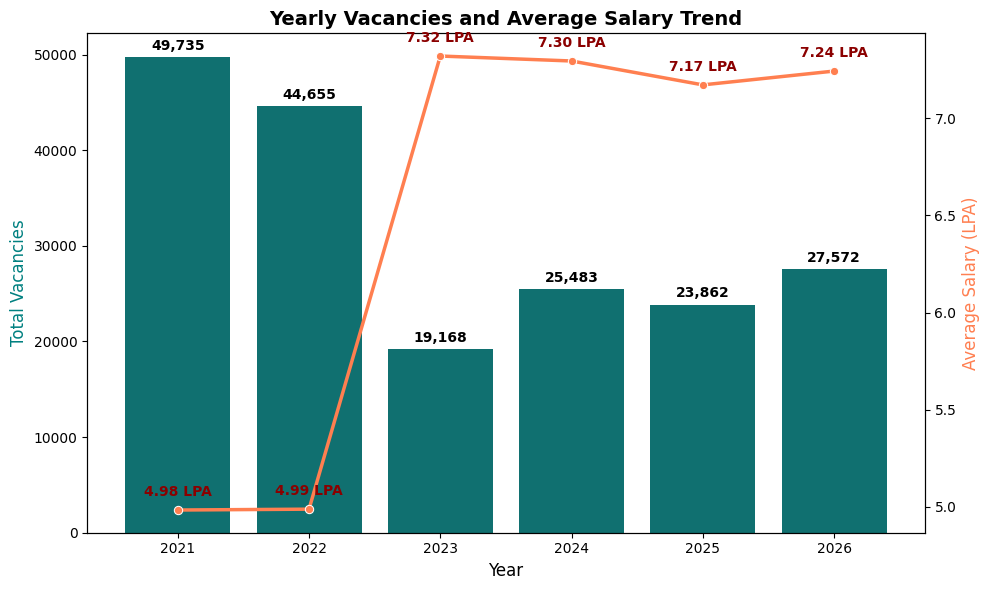

In [8]:
# Grouping data by Year
yearly_analysis = df.groupby('Year').agg({'Vacancies': 'sum', 'Avg_Salary_LPA': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting Vacancies Bar Chart
bar_plot = sns.barplot(x='Year', y='Vacancies', data=yearly_analysis, ax=ax1, color='teal')
ax1.set_title('Yearly Vacancies and Average Salary Trend', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Vacancies', fontsize=12, color='teal')

# Adding data labels on top of the Bars
for p in bar_plot.patches:
    bar_plot.annotate(format(int(p.get_height()), ','),
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', xytext=(0, 8),
                      textcoords='offset points', fontsize=10, fontweight='bold', color='black')

# Secondary y-axis for Salary Line Chart
ax2 = ax1.twinx()
line_plot = sns.lineplot(x=range(len(yearly_analysis)), y='Avg_Salary_LPA', data=yearly_analysis,
                         ax=ax2, color='coral', marker='o', linewidth=2.5)
ax2.set_ylabel('Average Salary (LPA)', fontsize=12, color='coral')

# Adding data labels on top of the Line Points
for x, y in zip(range(len(yearly_analysis)), yearly_analysis['Avg_Salary_LPA']):
    ax2.annotate(f"{y:.2f} LPA", (x, y), textcoords="offset points",
                 xytext=(0,10), ha='center', fontsize=10, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

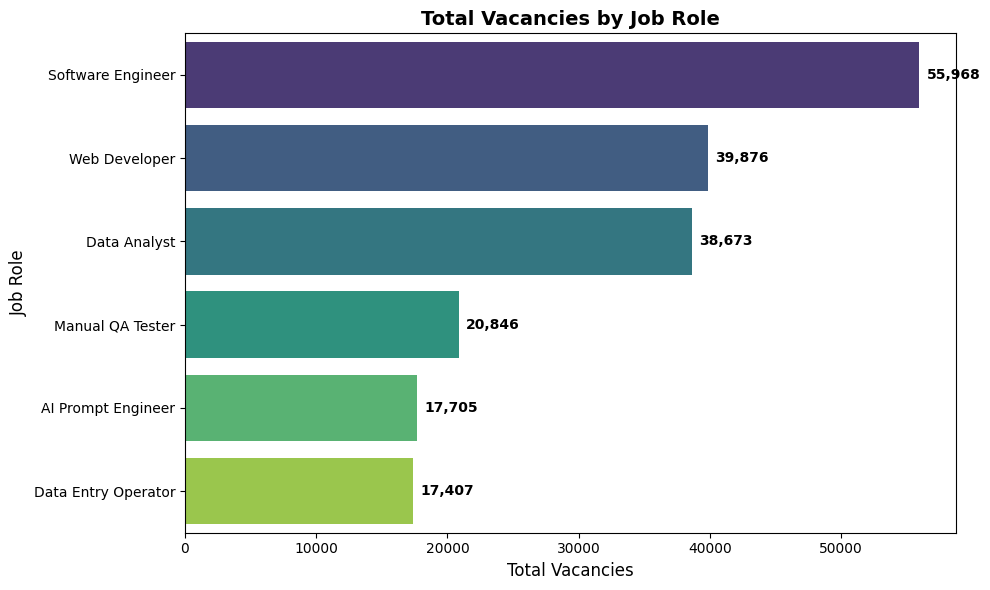

In [9]:
# Grouping data by Job_Role and calculating total vacancies
role_analysis = df.groupby('Job_Role').agg({
    'Vacancies': 'sum'
}).reset_index().sort_values(by='Vacancies', ascending=False)

# Setting up the figure size
plt.figure(figsize=(10, 6))

# Plotting horizontal bar chart
bar_plot = sns.barplot(x='Vacancies', y='Job_Role', data=role_analysis, hue='Job_Role', palette='viridis', legend=False)

# Adding clear labels and title
plt.title('Total Vacancies by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Total Vacancies', fontsize=12)
plt.ylabel('Job Role', fontsize=12)

# Adding numbers (Data Labels) at the end of each bar for easy understanding
for p in bar_plot.patches:
    width = p.get_width()
    bar_plot.annotate(format(int(width), ','),
                      (width, p.get_y() + p.get_height() / 2.),
                      ha='left', va='center', xytext=(5, 0),
                      textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Checking all unique Job Roles in the dataset
print("--- All Job Roles in Dataset ---")
print(df['Job_Role'].unique())

print("\n--- All Top Required Skills in Dataset ---")
print(df['Top_Required_Skill'].unique())

--- All Job Roles in Excel ---
['Manual QA Tester' 'Data Analyst' 'Data Entry Operator'
 'Software Engineer' 'AI Prompt Engineer' 'Web Developer']

--- All Top Required Skills in Excel ---
['Basic Manual Testing' 'Python, SQL & Power BI' 'Excel & Typing'
 'Java / C++' 'LLMs & Prompt Engineering' 'React JS & AI Copilot'
 'SQL & Excel' 'Cloud Computing & System Design' 'Basic Data Entry'
 'HTML/CSS/JavaScript' 'Manual Test Cases']


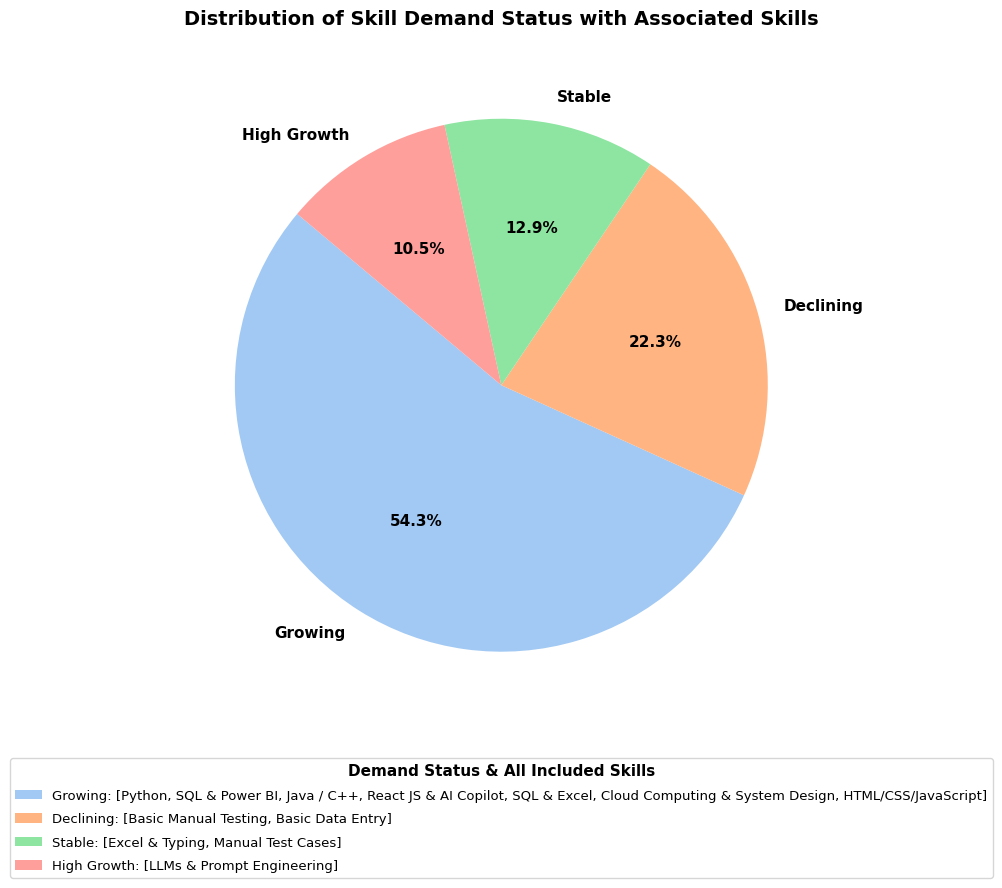

In [11]:
# Grouping data by Skill_Demand_Status
status_analysis = df['Skill_Demand_Status'].value_counts().reset_index()
status_analysis.columns = ['Skill_Demand_Status', 'Count']

# Fetching ALL unique skills for each category dynamically
skills_by_status = df.groupby('Skill_Demand_Status')['Top_Required_Skill'].unique()
legend_labels = []
for status in status_analysis['Skill_Demand_Status']:
    all_skills = ", ".join(skills_by_status[status])
    legend_labels.append(f"{status}: [{all_skills}]")

colors = sns.color_palette('pastel')[0:len(status_analysis)]

# Increased figure height so the legend fits below the chart
plt.figure(figsize=(12, 9))

wedges, texts, autotexts = plt.pie(status_analysis['Count'],
                                  labels=status_analysis['Skill_Demand_Status'],
                                  autopct='%1.1f%%',
                                  startangle=140,
                                  colors=colors,
                                  textprops={'fontsize': 11, 'fontweight': 'bold'})

# Moved the legend box below the chart
plt.legend(wedges, legend_labels, title="Demand Status & All Included Skills",
           title_fontproperties={'weight':'bold', 'size': 11},
           loc="upper center", bbox_to_anchor=(0.5, -0.05), fontsize=9.5, ncol=1, labelspacing=0.8)

plt.title('Distribution of Skill Demand Status with Associated Skills', fontsize=14, fontweight='bold', pad=20)

# Adjust padding with tight_layout so the bottom text is not cut off
plt.tight_layout()
plt.show()